# Superstore Sales Analysis

A business -focused analysis of real US retail sales data (20142017),buit with pandas and matplotilib.

## Step 1: Loding data

In [156]:
import pandas as pd
df = pd.read_csv("SuperStore Sales DataSet.csv", encoding="latin1")

In [157]:
df.shape

(5901, 23)

In [158]:
df.head()

,Row ID+O6G3A1:R6,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Category,Sub-Category,Product Name,Sales,Quantity,Profit,Returns,Payment Mode,ind1,ind2
0,4918,CA-2019-160304,1/1/2019,1/7/2019,Standard Class,BM-11575,Brendan Murry,Corporate,United States,Gaithersburg,...,Furniture,Bookcases,"Bush Westfield Collection Bookcases, Medium Ch...",73.94,1,28.2668,NaN,Online,NaN,NaN
1,4919,CA-2019-160304,1/2/2019,1/7/2019,Standard Class,BM-11575,Brendan Murry,Corporate,United States,Gaithersburg,...,Furniture,Bookcases,"Bush Westfield Collection Bookcases, Medium Ch...",173.94,3,38.2668,NaN,Online,NaN,NaN
2,4920,CA-2019-160304,1/2/2019,1/7/2019,Standard Class,BM-11575,Brendan Murry,Corporate,United States,Gaithersburg,...,Technology,Phones,GE 30522EE2,231.98,2,67.2742,NaN,Cards,NaN,NaN
3,3074,CA-2019-125206,1/3/2019,1/5/2019,First Class,LR-16915,Lena Radford,Consumer,United States,Los Angeles,...,Office Supplies,Storage,Recycled Steel Personal File for Hanging File ...,114.46,2,28.6150,NaN,Online,NaN,NaN
4,8604,US-2019-116365,1/3/2019,1/8/2019,Standard Class,CA-12310,Christine Abelman,Corporate,United States,San Antonio,...,Technology,Accessories,Imation Clip USB flash drive - 8 GB,30.08,2,-5.2640,NaN,Online,NaN,NaN


## Step 2 : Data Audit 
checking column names,data types,missing values, and duplicates before doing any analysis.

In [159]:

df.columns.tolist()

['Row ID+O6G3A1:R6',
 'Order ID',
 'Order Date',
 'Ship Date',
 'Ship Mode',
 'Customer ID',
 'Customer Name',
 'Segment',
 'Country',
 'City',
 'State',
 'Region',
 'Product ID',
 'Category',
 'Sub-Category',
 'Product Name',
 'Sales',
 'Quantity',
 'Profit',
 'Returns',
 'Payment Mode',
 'ind1',
 'ind2']

In [160]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5901 entries, 0 to 5900
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Row ID+O6G3A1:R6  5901 non-null   int64  
 1   Order ID          5901 non-null   str    
 2   Order Date        5901 non-null   str    
 3   Ship Date         5901 non-null   str    
 4   Ship Mode         5901 non-null   str    
 5   Customer ID       5901 non-null   str    
 6   Customer Name     5901 non-null   str    
 7   Segment           5901 non-null   str    
 8   Country           5901 non-null   str    
 9   City              5901 non-null   str    
 10  State             5901 non-null   str    
 11  Region            5901 non-null   str    
 12  Product ID        5901 non-null   str    
 13  Category          5901 non-null   str    
 14  Sub-Category      5901 non-null   str    
 15  Product Name      5901 non-null   str    
 16  Sales             5901 non-null   float64
 17  Quanti

In [161]:
df.isna().sum()
(df.isna().sum()/len(df))*100

Row ID+O6G3A1:R6      0.000000
Order ID              0.000000
Order Date            0.000000
Ship Date             0.000000
Ship Mode             0.000000
Customer ID           0.000000
Customer Name         0.000000
Segment               0.000000
Country               0.000000
City                  0.000000
State                 0.000000
Region                0.000000
Product ID            0.000000
Category              0.000000
Sub-Category          0.000000
Product Name          0.000000
Sales                 0.000000
Quantity              0.000000
Profit                0.000000
Returns              95.136418
Payment Mode          0.000000
ind1                100.000000
ind2                100.000000
dtype: float64

In [162]:
df.duplicated().sum()

np.int64(0)

**Finding :** The dataset contains 5901 rows and 23 cloumns.No duplicate were found.
The columns "Return","ind1","ind2" have a large number of missing values and apperar to add little analytical value,so they will  be removed during cleaning.

## Step  3 : Data Cleaning

In [163]:
# Fixing corrupted column name

In [164]:
df=df.rename(columns={"Row ID+O6G3A1:R6":"Row ID"})


In [165]:
# Drop columns that are mostly empyty

In [166]:
df=df.drop(columns=["Returns","ind1","ind2"])

In [167]:
# Converting order Date to proper data type

In [168]:
df["Order Date"] =pd.to_datetime(df["Order Date"],errors ="coerce")


In [169]:
# confirm cleaning worked

In [170]:
df.columns.tolist()

['Row ID',
 'Order ID',
 'Order Date',
 'Ship Date',
 'Ship Mode',
 'Customer ID',
 'Customer Name',
 'Segment',
 'Country',
 'City',
 'State',
 'Region',
 'Product ID',
 'Category',
 'Sub-Category',
 'Product Name',
 'Sales',
 'Quantity',
 'Profit',
 'Payment Mode']

In [171]:
# Remove hidden spaces from column headers

In [172]:
df.columns=df.columns.str.strip()

In [173]:
df.dtypes

Row ID                    int64
Order ID                    str
Order Date       datetime64[us]
Ship Date                   str
Ship Mode                   str
Customer ID                 str
Customer Name               str
Segment                     str
Country                     str
City                        str
State                       str
Region                      str
Product ID                  str
Category                    str
Sub-Category                str
Product Name                str
Sales                   float64
Quantity                  int64
Profit                  float64
Payment Mode                str
dtype: object


**Finding :** Renamed the corrupted first column to "Row ID". Dropped "Return","ind1",and "ind2" since they were mostly or entirely empty.Converted "Order Date " from text to a proper datetime format so it can be used for time-based analysis later.


## Step 4 :Business Analysis

In [174]:
# Total Sales and profit


In [175]:
df["Sales"].sum()

np.float64(1565804.3232)

In [176]:
df["Profit"].sum()

np.float64(175262.1059)

In [177]:
# Sales by Region

In [178]:
df.groupby("Region")["Sales"].sum().sort_values(ascending=False)

Region
West       522441.0520
East       450234.6660
Central    341007.5242
South      252121.0810
Name: Sales, dtype: float64

In [179]:
# profit by Sub-Category   

In [180]:
df.groupby("Sub-Category")["Profit"].sum().sort_values(ascending=False)



Sub-Category
Copiers        42774.5828
Accessories    25336.6455
Phones         22308.9179
Paper          21112.3779
Binders        17885.3759
Storage        13607.0875
Chairs         13406.7032
Appliances     13166.6098
Furnishings     8034.4328
Art             3635.9257
Envelopes       3508.5073
Labels          2937.2212
Fasteners        598.4175
Machines          38.1024
Bookcases       -342.8883
Supplies       -1654.2767
Tables        -11091.6365
Name: Profit, dtype: float64

In [181]:
# profit by Category   

In [182]:
df.groupby("Category")["Profit"].sum().sort_values(ascending=False)

Category
Technology         90458.2486
Office Supplies    74797.2461
Furniture          10006.6112
Name: Profit, dtype: float64

In [183]:
df[df["Category"]=="Furniture"].groupby("Sub-Category")["Profit"].sum().sort_values(ascending=False)


Sub-Category
Chairs         13406.7032
Furnishings     8034.4328
Bookcases       -342.8883
Tables        -11091.6365
Name: Profit, dtype: float64

In [184]:
df[df["Category"]=="Office Supplies"].groupby("Sub-Category")["Profit"].sum().sort_values(ascending=False)

Sub-Category
Paper         21112.3779
Binders       17885.3759
Storage       13607.0875
Appliances    13166.6098
Art            3635.9257
Envelopes      3508.5073
Labels         2937.2212
Fasteners       598.4175
Supplies      -1654.2767
Name: Profit, dtype: float64

In [185]:
df[df["Category"]=="Technology"].groupby("Sub-Category")["Profit"].sum().sort_values(ascending=False)


Sub-Category
Copiers        42774.5828
Accessories    25336.6455
Phones         22308.9179
Machines          38.1024
Name: Profit, dtype: float64

In [186]:
# Top 5 product name by Sales

In [187]:
df.groupby("Product Name")["Sales"].sum().sort_values(ascending=False).head(5)


Product Name
3D Systems Cube Printer, 2nd Generation, Magenta    14334.890
Canon imageCLASS 2200 Advanced Copier               14076.824
Hewlett Packard LaserJet 3310 Copier                13837.732
GBC DocuBind TL300 Electric Binding System          12890.258
GBC DocuBind P400 Electric Binding System           12577.108
Name: Sales, dtype: float64

In [188]:
#Top 5 Sales by State

In [189]:
df.groupby("State")["Sales"].sum().sort_values(ascending=False).head(5)

State
California      335190.2560
New York        186748.0970
Texas           116261.9302
Washington       92975.1800
Pennsylvania     82354.9500
Name: Sales, dtype: float64

In [190]:
#Top 5 Sales by City

In [191]:
df.groupby("City")["Sales"].sum().sort_values(ascending=False).head(5)

City
New York City    154919.6990
Los Angeles      120017.4405
San Francisco     80891.4220
Seattle           77924.5420
Philadelphia      77305.4400
Name: Sales, dtype: float64

In [192]:
# Top 5 profit by State

In [193]:
df.groupby("State")["Profit"].sum().sort_values(ascending=False).head(5)

State
California    49372.1750
New York      41012.0212
Washington    21466.6555
Michigan      17480.2806
Indiana       15524.6596
Name: Profit, dtype: float64

In [194]:
# Top 5 profit by City

In [195]:
df.groupby("City")["Profit"].sum().sort_values().head(5)

City
Philadelphia   -8065.9684
Lancaster      -7207.3791
Houston        -7197.7160
Chicago        -6497.3566
Burlington     -4814.8042
Name: Profit, dtype: float64

In [196]:
#Total state Count profit in Negative

In [197]:
df.groupby("State")["Profit"].sum().loc[lambda x: x<0].count()

np.int64(10)

In [198]:
# This shows the 5 states causing the biggest losses

In [199]:
df.groupby("State")["Profit"].sum().sort_values(ascending=True).head(5)


State
Texas          -14078.1598
Illinois        -9554.6539
Ohio            -9339.4223
Pennsylvania    -9297.7975
Colorado        -5825.5857
Name: Profit, dtype: float64

In [200]:
#Total Cities Count profit in Negative

In [201]:
df.groupby("City")["Profit"].sum().loc[lambda x: x<0].count()

np.int64(93)

In [202]:
# This shows the 10 City causing the biggest losses

In [203]:
df.groupby ("City")["Profit"].sum().sort_values(ascending=True).head(10)

City
Philadelphia   -8065.9684
Lancaster      -7207.3791
Houston        -7197.7160
Chicago        -6497.3566
Burlington     -4814.8042
Louisville     -2338.8303
Phoenix        -2054.4460
Dallas         -1983.7422
Memphis        -1466.4888
Aurora         -1444.8620
Name: Profit, dtype: float64

In [204]:
# Monthly Sales Trend

In [205]:
monthly_sales=df.set_index("Order Date")["Sales"].resample("ME").sum()
print(monthly_sales)

Order Date
2019-01-31     18616.4310
2019-02-28     19978.8150
2019-03-31     51715.8750
2019-04-30     38750.0390
2019-05-31     50987.7280
2019-06-30     40344.5340
2019-07-31     39261.9630
2019-08-31     31115.3743
2019-09-30     73410.0249
2019-10-31     42687.7450
2019-11-30     79411.9658
2019-12-31     78399.0430
2020-01-31     54763.3740
2020-02-29     52068.1334
2020-03-31     64229.3528
2020-04-30     50807.5361
2020-05-31     66750.1102
2020-06-30     69242.7257
2020-07-31     60077.4160
2020-08-31     77338.8880
2020-09-30    119803.6520
2020-10-31     88896.9232
2020-11-30    130960.8250
2020-12-31    166185.8488
Freq: ME, Name: Sales, dtype: float64


## Step 5 : Root Cause Analysis

In [206]:
City = df.groupby("City").agg(
    profit=("Profit","sum"),
    orders =("Order ID","nunique")
).reset_index()
loss_cities =City[City["profit"]<0]
real_loss =loss_cities[loss_cities["orders"]>=5]
print("total loss cities:",len(loss_cities))
print("Real Loss cities(5+ orders) :",len(real_loss))
df[df["City"].isin(real_loss["City"])].groupby("Sub-Category")["Profit"].sum().sort_values()



total loss cities: 93
Real Loss cities(5+ orders) : 31


Sub-Category
Binders       -18640.2457
Machines      -15979.8931
Tables        -11409.3541
Bookcases      -3185.2508
Chairs         -2551.3191
Appliances     -2366.4778
Furnishings    -1992.0059
Supplies       -1534.3772
Storage         -401.3636
Phones          -345.3867
Fasteners        113.9191
Labels           229.7121
Art              328.1959
Envelopes        544.0825
Accessories     1961.6264
Copiers         2275.9746
Paper           3163.4419
Name: Profit, dtype: float64

**Finding:** Of the 93 loss-making cities, only 31 have meaningful order volume (5+ orders); the other 62 are 1-4 order cities where a single transaction can flip them negative. Within the 31 real loss-making cities, **Binders** and **Machines** are the two biggest contributors to the loss -- even though both are profitable Sub-Categories overall. This points to something specific happening with these two product types in these cities, not a company-wide pricing issue.

## Step 6 : Visualization

In [207]:
import matplotlib.pyplot as plt

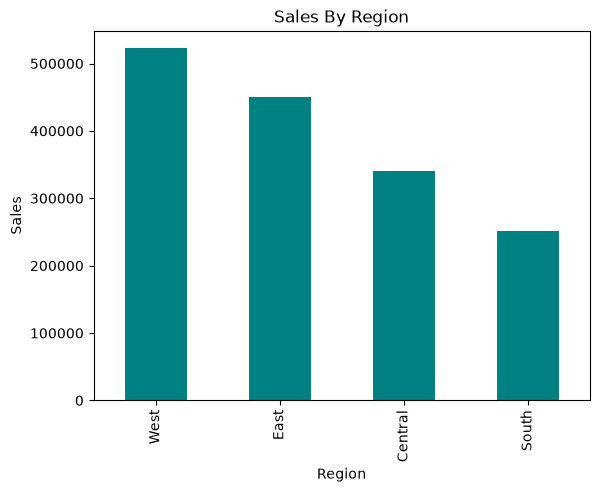

In [208]:
df.groupby("Region")["Sales"].sum().sort_values(ascending=False).plot(kind="bar",color ="teal")
plt.title("Sales By Region")
plt.xlabel("Region")
plt.ylabel("Sales")
plt.show()

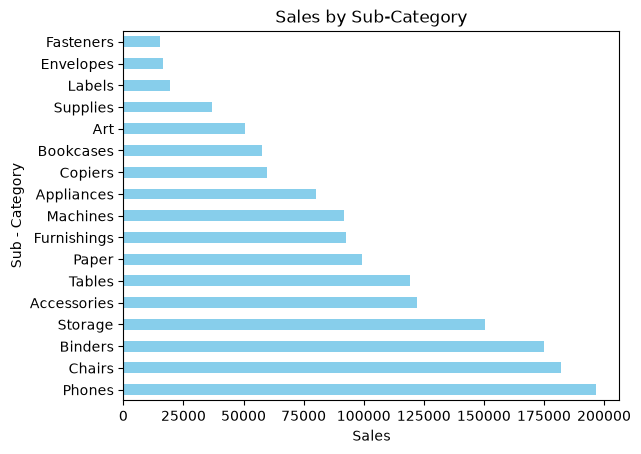

In [209]:
df.groupby("Sub-Category")["Sales"].sum().sort_values(ascending=False).plot(kind="barh",color ="skyblue")
plt.title("Sales by Sub-Category")
plt.xlabel("Sales")
plt.ylabel("Sub - Category")
plt.show()


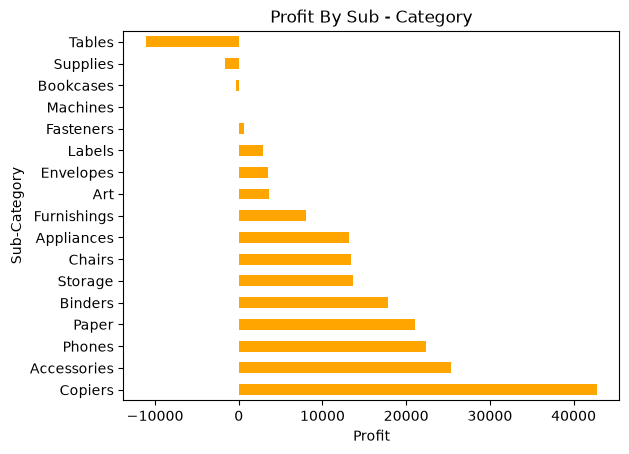

In [210]:
df.groupby("Sub-Category")["Profit"].sum().sort_values(ascending=False).plot(kind="barh",color="orange")
plt.title("Profit By Sub - Category")
plt.xlabel("Profit")
plt.ylabel("Sub-Category")
plt.show()


In [211]:
#Top 5 Profit -Making States and Cities

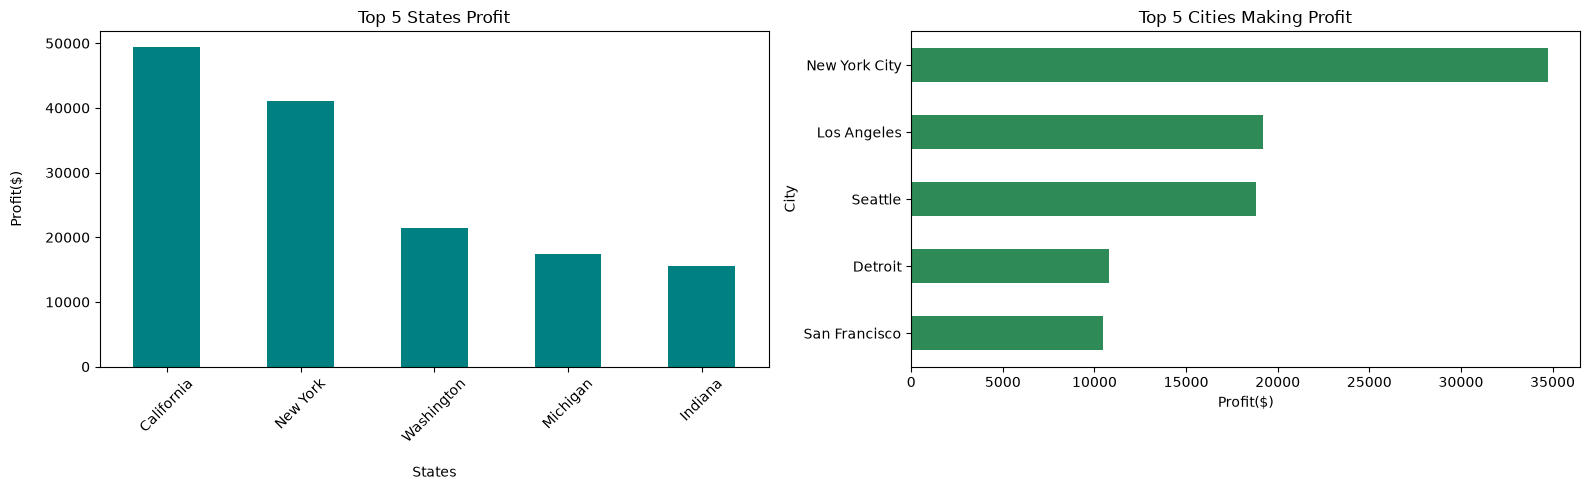

In [212]:
fig,axes=plt.subplots(1,2,figsize=(16,5))
# chore 1 : Plot Top 5 Profit -Making States (left side)
df.groupby("State")["Profit"].sum().sort_values(ascending=False).head(5).plot(kind="bar",ax=axes[0],color ="teal")
axes[0].set_title("Top 5 States Profit")
axes[0].set_ylabel("Profit($)",labelpad=15)
axes[0].set_xlabel("States",labelpad=15)
axes[0].tick_params(axis='x',rotation=45)

# chore 2 : Plot Top 5 Profit-making City (Right side)
df.groupby("City")["Profit"].sum().sort_values(ascending=False).head(5).plot(kind="barh",ax=axes[1],color="seagreen")
axes[1].set_title("Top 5 Cities Making Profit")
axes[1].set_ylabel("City")
axes[1].set_xlabel("Profit($)")
axes[1].invert_yaxis()
plt.tight_layout()
plt.show()

In [213]:
#Top 5 Loss-making States and Cities

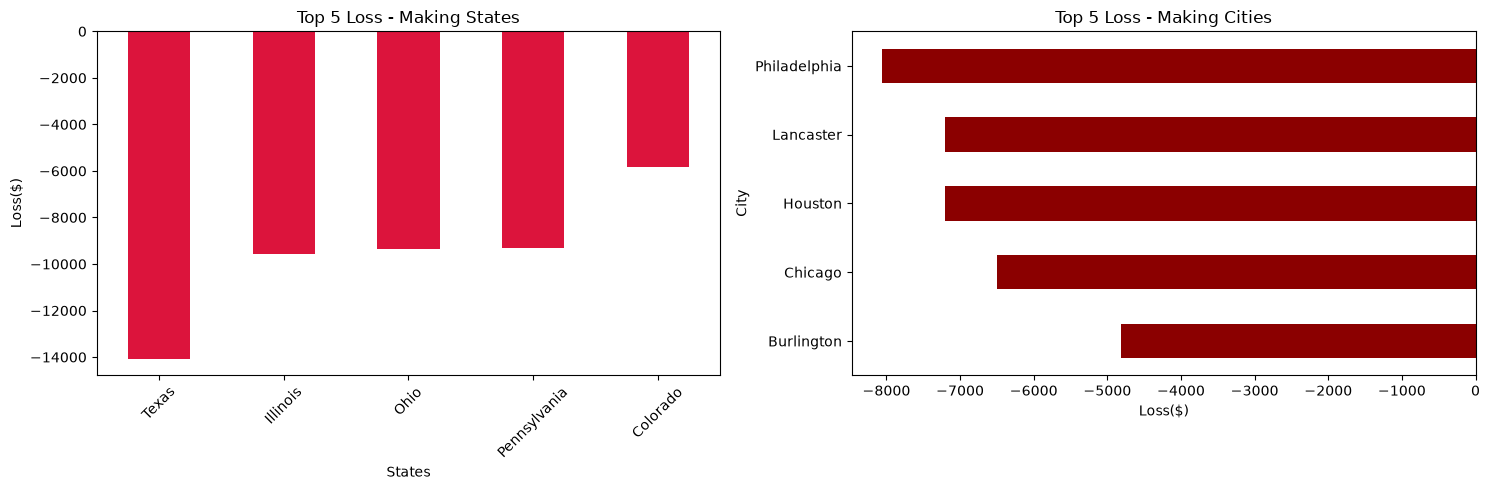

In [214]:
fig,axes=plt.subplots(1,2,figsize=(15,5))
# chore 1 : Plot Top 5 Loss-making States (left side)
df.groupby("State")["Profit"].sum().loc[lambda x:x<0].sort_values().head(5).plot(kind="bar",ax=axes[0],color="crimson")
axes[0].set_title("Top 5 Loss - Making States")                                                                          
axes[0].set_ylabel("Loss($)")
axes[0].set_xlabel("States")
axes[0].tick_params(axis='x',rotation=45)     
# chore 2 : Plot Top 5 Loss-making City (Right side)
df.groupby("City")["Profit"].sum().loc[lambda x : x<0 ].sort_values().head(5).plot(kind="barh",ax=axes[1],color="darkred")
axes[1].set_title("Top 5 Loss - Making Cities")
axes[1].set_ylabel("City")
axes[1].set_xlabel("Loss($)")
axes[1].invert_yaxis()
plt.tight_layout()
plt.show()






In [215]:
#Month Sales Trend

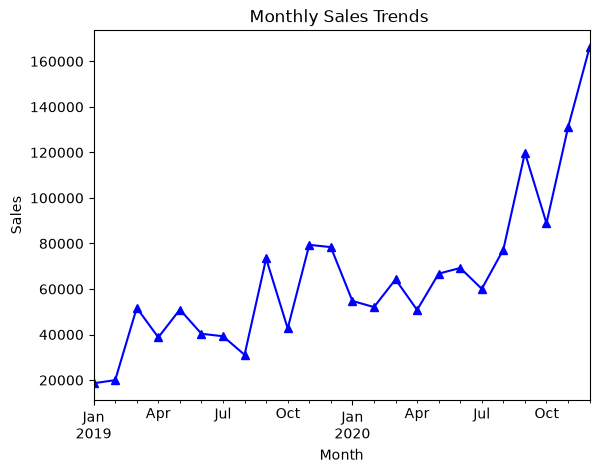

In [216]:
monthly_sales.plot(kind="line",marker="^",color ="blue")
plt.title("Monthly Sales Trends ")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

In [217]:
#Biggest Loss-Making Sub-Categories\n(inside the 31 real loss-making cities

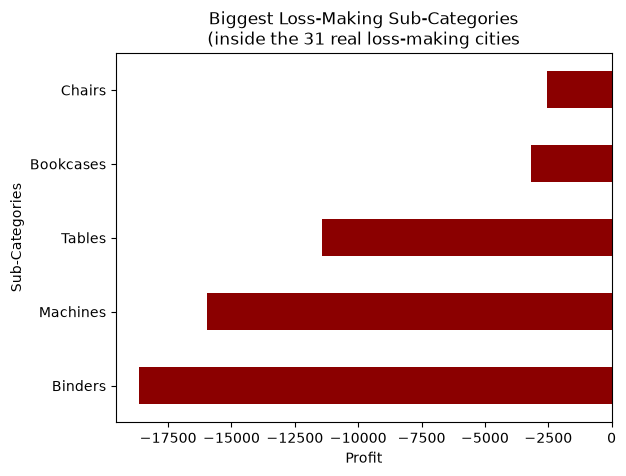

In [218]:
City =df.groupby("City").agg( 
    profit= ("Profit","sum"),
    orders=("Order ID","nunique")
).reset_index()
loss_cities= City[City["profit"]<0]
real_loss =loss_cities[loss_cities["orders"]>=5]
Sub_Loss =df[df["City"].isin(real_loss["City"])].groupby("Sub-Category")["Profit"].sum().sort_values()

Sub_Loss.head(5).plot(kind="barh",color="darkred")
plt.title("Biggest Loss-Making Sub-Categories\n(inside the 31 real loss-making cities")
plt.xlabel("Profit")
plt.ylabel("Sub-Categories")
plt.show()



**Conclusion & Key Findings**:

**What's Working:** The West region is our biggest sales driver. Also, our single highest-selling item is the 3D Systems Cube Printer, 2nd Generation, Magenta, bringing in over $14,000 in sales.

**The Profit Leaks:** High sales don't always mean high profit. The "Tables", "Supplies", and "Bookcases" sub-categories are actually losing the store money at the sub-category level.

**The Main Insight:** Our financial losses are not a massive nationwide failure. Instead, they are concentrated in 93 specific cities, spread across 10 states where the state's total profit is net negative overall (led by Texas, followed by states including Pennsylvania and Illinois -- both Houston, TX and Philadelphia, PA fall within this set of states).

**Root Cause:** Of those 93 cities, only 31 have meaningful order volume (5+ orders); the remaining 62 are low-volume cities where a single bad transaction is enough to flip them negative -- this is statistical noise, not a real pattern. Within the 31 real loss-making cities, **Binders** and **Machines** are the two biggest contributors to the loss, even though both Sub-Categories are profitable across the business overall.

**Final Recommendation:** This dataset does not contain a `Discount` field, so we cannot confirm discounting as the cause. Instead, the evidence points to something specific happening with Binders and Machines orders in these 31 cities -- most likely a small number of high-value or bulk orders, or a shipping/fulfillment cost issue -- rather than a company-wide pricing problem. The next step should be pulling the individual Binders and Machines transactions in these 31 cities to identify the exact orders driving the loss.